# EDA Report Notebook - Demand Story (4 Layers)

This notebook follows the requested storytelling flow:
1. Descriptive - what happened
2. Diagnostic - what factors are associated with revenue
3. Predictive - how well demand can be forecast
4. Prescriptive - what actions planning teams should take

Important wording note: all relationships are interpreted as *associations*, not causal claims.

In [7]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 5)

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for path in [cwd, *cwd.parents]:
        if (path / 'data' / 'processed').exists():
            return path
    raise FileNotFoundError('Could not locate project root with data/processed folder.')

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    out = np.zeros_like(y_true, dtype=float)
    out[mask] = 2.0 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]
    return 100.0 * out.mean()

def compute_metrics(y_true, y_pred, model_name):
    return {
        'model': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
        'MAPE_%': (np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-9, None))).mean() * 100,
        'sMAPE_%': smape(y_true, y_pred),
    }

def add_ts_features(df):
    out = df.copy().sort_values('date').reset_index(drop=True)
    out['day_of_week'] = out['date'].dt.dayofweek
    out['month'] = out['date'].dt.month
    out['day_of_year'] = out['date'].dt.dayofyear
    out['is_weekend'] = out['day_of_week'].isin([5, 6]).astype(int)
    for lag in [1, 7, 14, 28]:
        out[f'revenue_lag_{lag}'] = out['revenue'].shift(lag)
    out['revenue_roll_mean_7'] = out['revenue'].shift(1).rolling(7).mean()
    out['revenue_roll_std_7'] = out['revenue'].shift(1).rolling(7).std()
    out['revenue_roll_mean_28'] = out['revenue'].shift(1).rolling(28).mean()
    out['revenue_roll_std_28'] = out['revenue'].shift(1).rolling(28).std()
    return out

def fit_seasonal_trend_baseline(train_df):
    tmp = train_df.copy()
    tmp['year'] = tmp['date'].dt.year
    tmp['month'] = tmp['date'].dt.month
    tmp['day'] = tmp['date'].dt.day

    annual = tmp.groupby('year', as_index=False)['revenue'].sum().sort_values('year')
    yoy = annual['revenue'].pct_change().dropna()
    growth = (1.0 + yoy).prod() ** (1.0 / max(len(yoy), 1)) if len(yoy) else 1.0

    tmp['year_avg'] = tmp.groupby('year')['revenue'].transform('mean')
    tmp['rev_norm'] = tmp['revenue'] / tmp['year_avg']
    seasonal_profile = tmp.groupby(['month', 'day'], as_index=False)['rev_norm'].mean()

    latest_year = int(tmp['year'].max())
    base_level = annual.loc[annual['year'] == latest_year, 'revenue'].iloc[0] / 365.0
    return {
        'seasonal_profile': seasonal_profile,
        'growth': growth,
        'base_level': base_level,
        'base_year': latest_year,
    }

def predict_seasonal_trend(model_state, dates):
    future = pd.DataFrame({'date': pd.to_datetime(dates)})
    future['month'] = future['date'].dt.month
    future['day'] = future['date'].dt.day
    future['year'] = future['date'].dt.year
    future['years_ahead'] = future['year'] - model_state['base_year']
    out = future.merge(model_state['seasonal_profile'], on=['month', 'day'], how='left')
    out['rev_norm'] = out['rev_norm'].fillna(1.0)
    out['pred'] = model_state['base_level'] * (model_state['growth'] ** out['years_ahead']) * out['rev_norm']
    return out[['date', 'pred']]

def recursive_forecast_hgb(history_df, model, horizon_dates):
    history = history_df[['date', 'revenue']].copy().sort_values('date').reset_index(drop=True)
    preds = []
    for dt in pd.to_datetime(horizon_dates):
        series = history['revenue']
        row = {
            'day_of_week': dt.dayofweek,
            'month': dt.month,
            'day_of_year': dt.timetuple().tm_yday,
            'is_weekend': int(dt.dayofweek in [5, 6]),
            'revenue_lag_1': series.iloc[-1],
            'revenue_lag_7': series.iloc[-7],
            'revenue_lag_14': series.iloc[-14],
            'revenue_lag_28': series.iloc[-28],
            'revenue_roll_mean_7': series.iloc[-7:].mean(),
            'revenue_roll_std_7': series.iloc[-7:].std(ddof=1),
            'revenue_roll_mean_28': series.iloc[-28:].mean(),
            'revenue_roll_std_28': series.iloc[-28:].std(ddof=1),
        }
        x_row = pd.DataFrame([row]).fillna(0.0)
        pred = float(model.predict(x_row)[0])
        pred = max(0.0, pred)
        preds.append({'date': dt, 'pred': pred})
        history.loc[len(history)] = {'date': dt, 'revenue': pred}
    return pd.DataFrame(preds)

root = find_project_root()
processed = root / 'data' / 'processed'

sales = pd.read_csv(processed / 'sales.csv')
sales = sales.rename(columns={'Date': 'date', 'Revenue': 'revenue', 'COGS': 'cogs'})
sales['date'] = pd.to_datetime(sales['date'])
sales = sales.sort_values('date').reset_index(drop=True)

orders = pd.read_csv(processed / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(processed / 'order_items.csv')
returns = pd.read_csv(processed / 'returns.csv', parse_dates=['return_date'])
promotions = pd.read_csv(processed / 'promotions.csv', parse_dates=['start_date', 'end_date'])
web_traffic = pd.read_csv(processed / 'web_traffic.csv', parse_dates=['date'])
inventory = pd.read_csv(processed / 'inventory.csv', parse_dates=['snapshot_date'])

print('Loaded data from:', processed)
print('Sales date range:', sales['date'].min().date(), '->', sales['date'].max().date(), '| rows =', len(sales))

Loaded data from: C:\Users\ADMIN\Documents\learning - projects\DATATHON\datathon-hkbaleycb4\data\processed
Sales date range: 2012-07-04 -> 2022-12-31 | rows = 3833


## Layer 1 - Descriptive (What happened?)

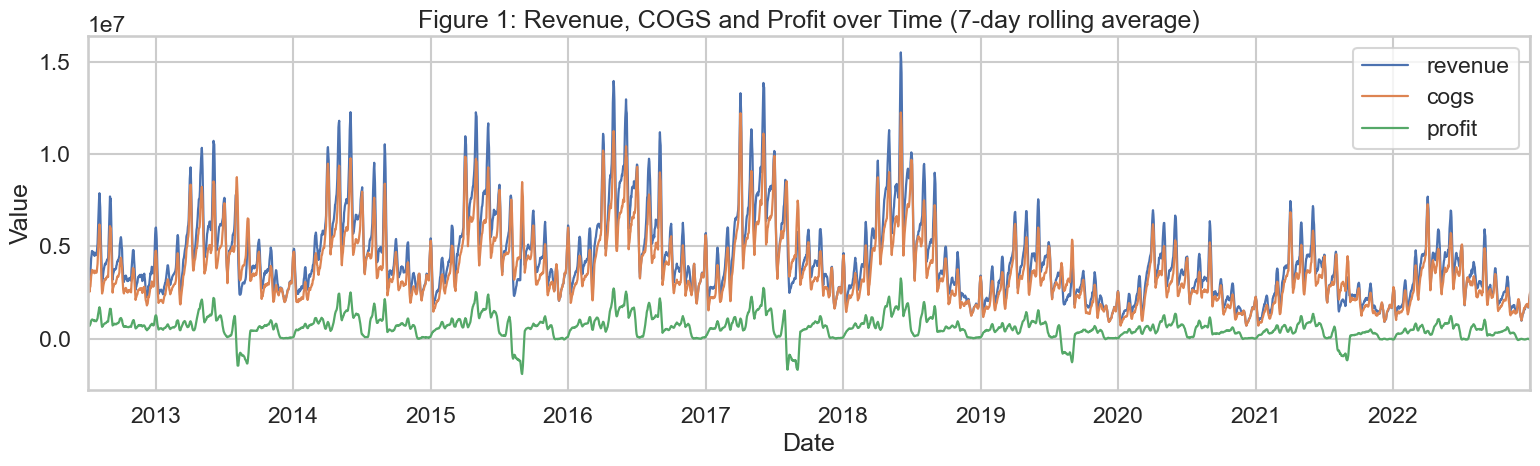

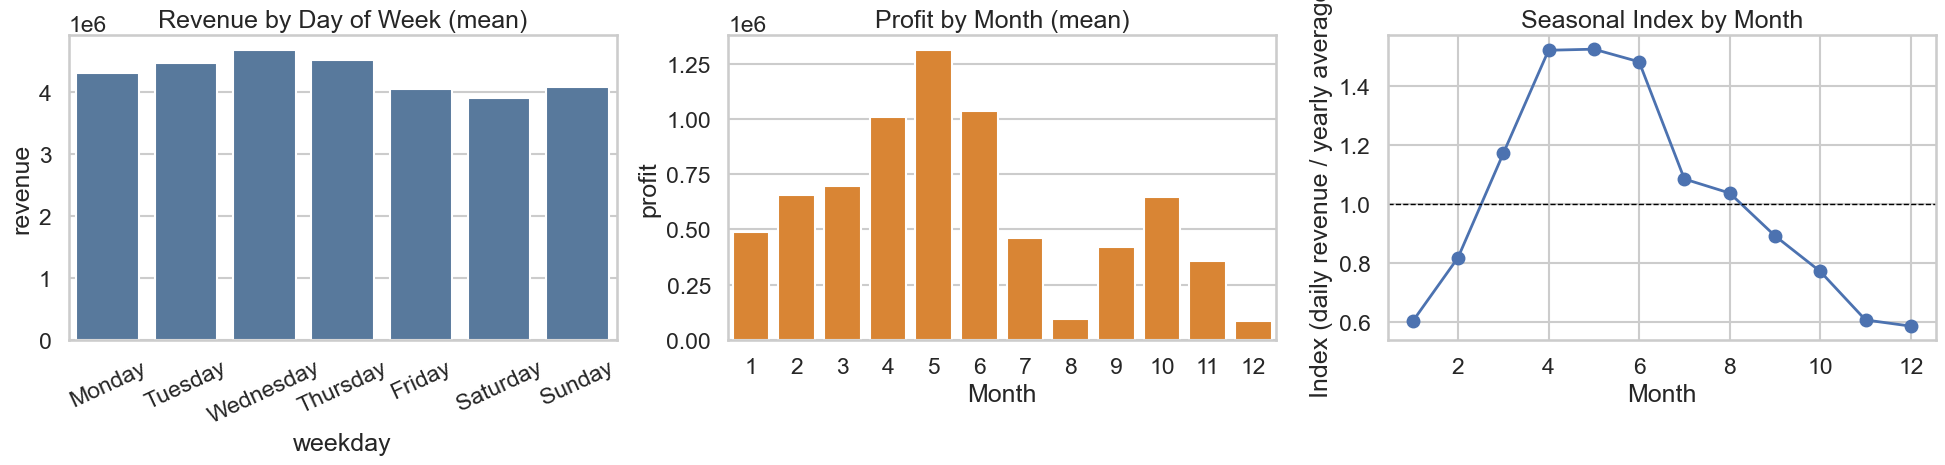

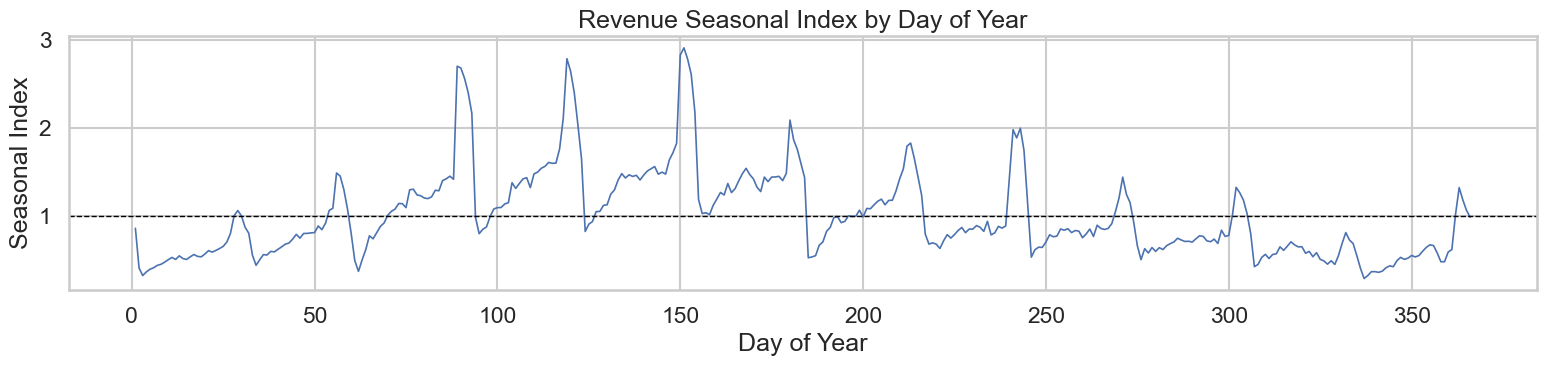

,count,mean,std,min,25%,50%,75%,max
revenue,3833.0,4286584.030,2624840.198,279813.940,2471088.820,3647303.900,5350877.200,2.090527e+07
cogs,3833.0,3695134.495,2219788.769,236576.310,2150580.230,3161112.990,4637293.920,1.653586e+07
profit,3833.0,591449.535,666196.023,-2567311.720,229274.050,544554.380,876080.980,4.369414e+06
gross_margin,3833.0,0.125,0.127,-0.575,0.083,0.178,0.203,2.870000e-01


In [8]:
daily = sales.copy()
daily['profit'] = daily['revenue'] - daily['cogs']
daily['gross_margin'] = np.where(daily['revenue'] != 0, daily['profit'] / daily['revenue'], np.nan)
daily['weekday'] = daily['date'].dt.day_name()
daily['month'] = daily['date'].dt.month
daily['year'] = daily['date'].dt.year
daily['day_of_year'] = daily['date'].dt.dayofyear

daily_revenue = daily[['date', 'revenue']].copy()
daily_cogs = daily[['date', 'cogs']].copy()
daily_profit = daily[['date', 'profit']].copy()
daily['yearly_avg_revenue'] = daily.groupby('year')['revenue'].transform('mean')
daily['seasonal_index'] = daily['revenue'] / daily['yearly_avg_revenue']

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
revenue_by_day_of_week = daily.groupby('weekday', as_index=False)['revenue'].mean()
revenue_by_day_of_week['weekday'] = pd.Categorical(revenue_by_day_of_week['weekday'], categories=weekday_order, ordered=True)
revenue_by_day_of_week = revenue_by_day_of_week.sort_values('weekday')
profit_by_month = daily.groupby('month', as_index=False)['profit'].mean()
seasonal_month = daily.groupby('month', as_index=False)['seasonal_index'].mean()
seasonal_doy = daily.groupby('day_of_year', as_index=False)['seasonal_index'].mean()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
plot_df = daily.set_index('date')[['revenue', 'cogs', 'profit']].rolling(7, min_periods=1).mean()
plot_df.plot(ax=ax, linewidth=1.6)
ax.set_title('Figure 1: Revenue, COGS and Profit over Time (7-day rolling average)')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(data=revenue_by_day_of_week, x='weekday', y='revenue', ax=axes[0], color='#4C78A8')
axes[0].set_title('Revenue by Day of Week (mean)')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=profit_by_month, x='month', y='profit', ax=axes[1], color='#F58518')
axes[1].set_title('Profit by Month (mean)')
axes[1].set_xlabel('Month')

axes[2].plot(seasonal_month['month'], seasonal_month['seasonal_index'], marker='o', linewidth=2)
axes[2].axhline(1.0, linestyle='--', color='black', linewidth=1)
axes[2].set_title('Seasonal Index by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Index (daily revenue / yearly average)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(16, 4))
ax.plot(seasonal_doy['day_of_year'], seasonal_doy['seasonal_index'], linewidth=1.2)
ax.axhline(1.0, linestyle='--', color='black', linewidth=1)
ax.set_title('Revenue Seasonal Index by Day of Year')
ax.set_xlabel('Day of Year')
ax.set_ylabel('Seasonal Index')
plt.tight_layout()
plt.show()

display(daily[['revenue', 'cogs', 'profit', 'gross_margin']].describe().T.round(3))

### COVID period insight (2020-2022)

Bổ sung góc nhìn riêng cho giai đoạn đại dịch để kiểm tra biến động về mức doanh thu, độ biến động và biên lợi nhuận.

Lưu ý diễn giải: các kết quả dưới đây là mối liên hệ quan sát được (*associated with / consistent with*), không phải kết luận nhân quả.

,year,revenue_total,cogs_total,profit_total,gross_margin_mean,daily_revenue_mean,daily_revenue_std,revenue_yoy_%,profit_yoy_%
0,2018,1.850122e+09,1.542176e+09,3.079467e+08,0.157,5068828.647,3168626.257,NaN,NaN
1,2019,1.136801e+09,1.005203e+09,1.315986e+08,0.102,3114524.497,1642733.648,-38.555,-57.266
2,2020,1.054512e+09,8.860851e+08,1.684271e+08,0.153,2881180.762,1637312.447,-7.239,27.985
3,2021,1.043040e+09,9.411301e+08,1.019097e+08,0.079,2857643.341,1644090.603,-1.088,-39.493
4,2022,1.169749e+09,1.020420e+09,1.493287e+08,0.121,3204791.320,1676107.523,12.148,46.530


,metric,pre_covid_2017_2019,covid_2020_2022,change_%
0,avg_daily_revenue,4473139.930,2981113.878,-33.355
1,daily_revenue_std,2883256.925,1658649.105,-42.473
2,avg_gross_margin,0.119,0.118,-0.976


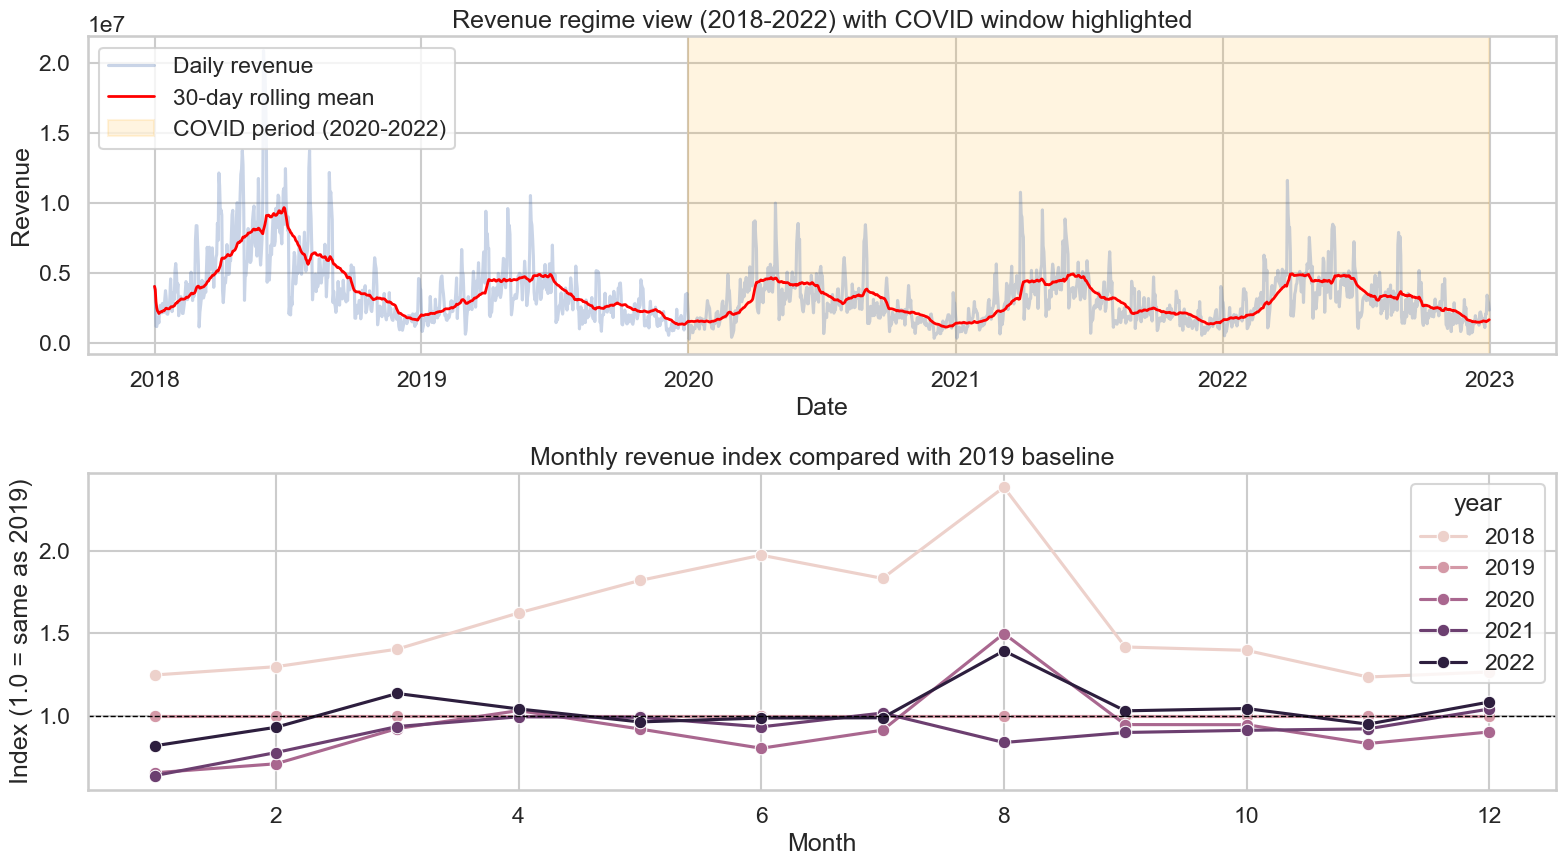

COVID-period data comments (2020-2022):
- Average daily revenue changed by -33.36% vs pre-COVID (2017-2019).
- Revenue volatility (std) changed by -42.47% vs pre-COVID.
- Average gross margin changed by -0.12 percentage points.
- Overall pattern suggests a structural demand shift during 2020-2022, consistent with pandemic-era disruption and adaptation.


In [9]:
covid_window = daily[(daily['date'] >= '2020-01-01') & (daily['date'] <= '2022-12-31')].copy()
pre_covid_window = daily[(daily['date'] >= '2017-01-01') & (daily['date'] <= '2019-12-31')].copy()

yearly_covid_view = (
    daily[daily['date'].dt.year.between(2018, 2022)]
    .assign(year=lambda d: d['date'].dt.year)
    .groupby('year', as_index=False)
    .agg(
        revenue_total=('revenue', 'sum'),
        cogs_total=('cogs', 'sum'),
        profit_total=('profit', 'sum'),
        gross_margin_mean=('gross_margin', 'mean'),
        daily_revenue_mean=('revenue', 'mean'),
        daily_revenue_std=('revenue', 'std'),
    )
)
yearly_covid_view['revenue_yoy_%'] = yearly_covid_view['revenue_total'].pct_change() * 100
yearly_covid_view['profit_yoy_%'] = yearly_covid_view['profit_total'].pct_change() * 100
display(yearly_covid_view.round(3))

comparison = pd.DataFrame(
    {
        'metric': ['avg_daily_revenue', 'daily_revenue_std', 'avg_gross_margin'],
        'pre_covid_2017_2019': [
            pre_covid_window['revenue'].mean(),
            pre_covid_window['revenue'].std(),
            pre_covid_window['gross_margin'].mean(),
        ],
        'covid_2020_2022': [
            covid_window['revenue'].mean(),
            covid_window['revenue'].std(),
            covid_window['gross_margin'].mean(),
        ],
    }
)
comparison['change_%'] = (
    (comparison['covid_2020_2022'] - comparison['pre_covid_2017_2019'])
    / comparison['pre_covid_2017_2019']
) * 100
display(comparison.round(3))

focus = daily[daily['date'].dt.year.between(2018, 2022)].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
axes[0].plot(focus['date'], focus['revenue'], alpha=0.3, label='Daily revenue')
axes[0].plot(
    focus['date'],
    focus['revenue'].rolling(30, min_periods=1).mean(),
    linewidth=2,
    color='red',
    label='30-day rolling mean',
)
axes[0].axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2022-12-31'), color='orange', alpha=0.12, label='COVID period (2020-2022)')
axes[0].set_title('Revenue regime view (2018-2022) with COVID window highlighted')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue')
axes[0].legend(loc='upper left')

monthly_profile = (
    focus.assign(year=focus['date'].dt.year, month=focus['date'].dt.month)
    .groupby(['year', 'month'], as_index=False)['revenue']
    .mean()
)
base_2019 = monthly_profile[monthly_profile['year'] == 2019][['month', 'revenue']].rename(columns={'revenue': 'baseline_2019'})
monthly_profile = monthly_profile.merge(base_2019, on='month', how='left')
monthly_profile['index_vs_2019'] = monthly_profile['revenue'] / monthly_profile['baseline_2019']
sns.lineplot(data=monthly_profile, x='month', y='index_vs_2019', hue='year', marker='o', ax=axes[1])
axes[1].axhline(1.0, linestyle='--', color='black', linewidth=1)
axes[1].set_title('Monthly revenue index compared with 2019 baseline')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Index (1.0 = same as 2019)')

plt.tight_layout()
plt.show()

delta_mean = (comparison.loc[comparison['metric'] == 'avg_daily_revenue', 'change_%'].iloc[0])
delta_vol = (comparison.loc[comparison['metric'] == 'daily_revenue_std', 'change_%'].iloc[0])
delta_margin_pp = (
    comparison.loc[comparison['metric'] == 'avg_gross_margin', 'covid_2020_2022'].iloc[0]
    - comparison.loc[comparison['metric'] == 'avg_gross_margin', 'pre_covid_2017_2019'].iloc[0]
) * 100

print('COVID-period data comments (2020-2022):')
print(f"- Average daily revenue changed by {delta_mean:+.2f}% vs pre-COVID (2017-2019).")
print(f"- Revenue volatility (std) changed by {delta_vol:+.2f}% vs pre-COVID.")
print(f"- Average gross margin changed by {delta_margin_pp:+.2f} percentage points.")
print('- Overall pattern suggests a structural demand shift during 2020-2022, consistent with pandemic-era disruption and adaptation.')

## Layer 2 - Diagnostic (Why did it happen?)

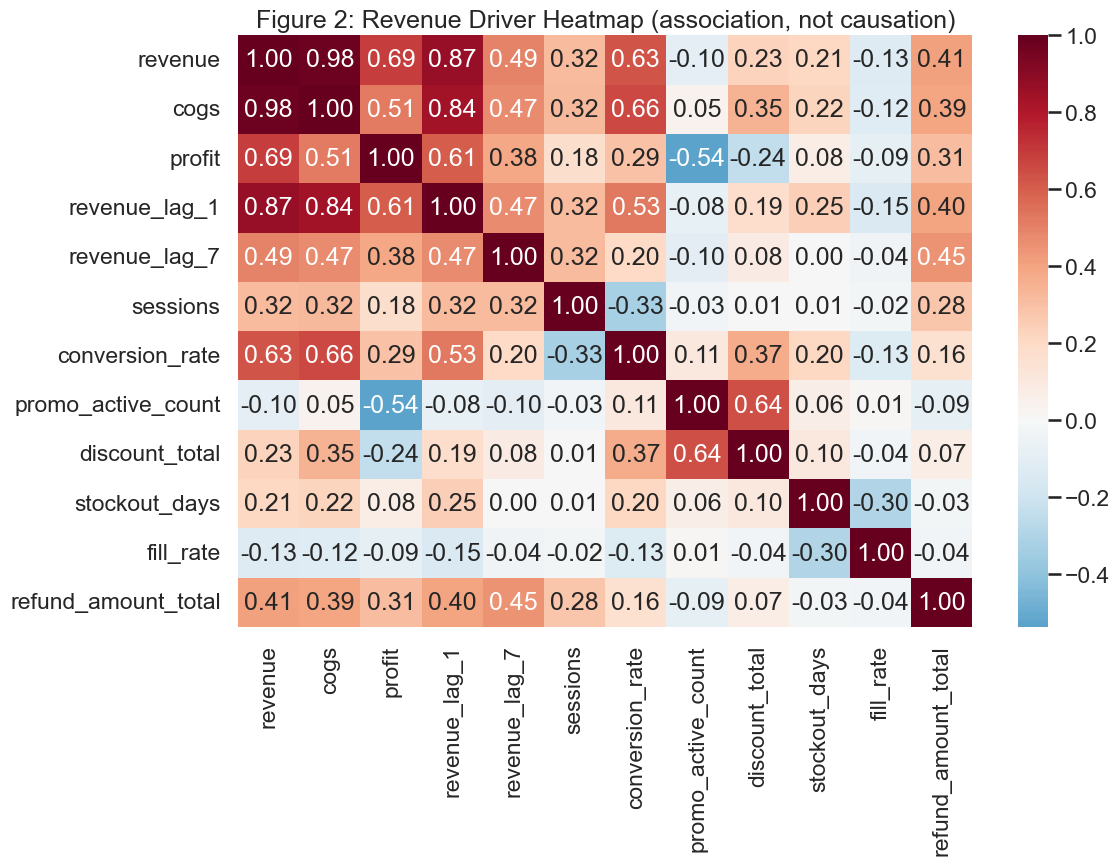

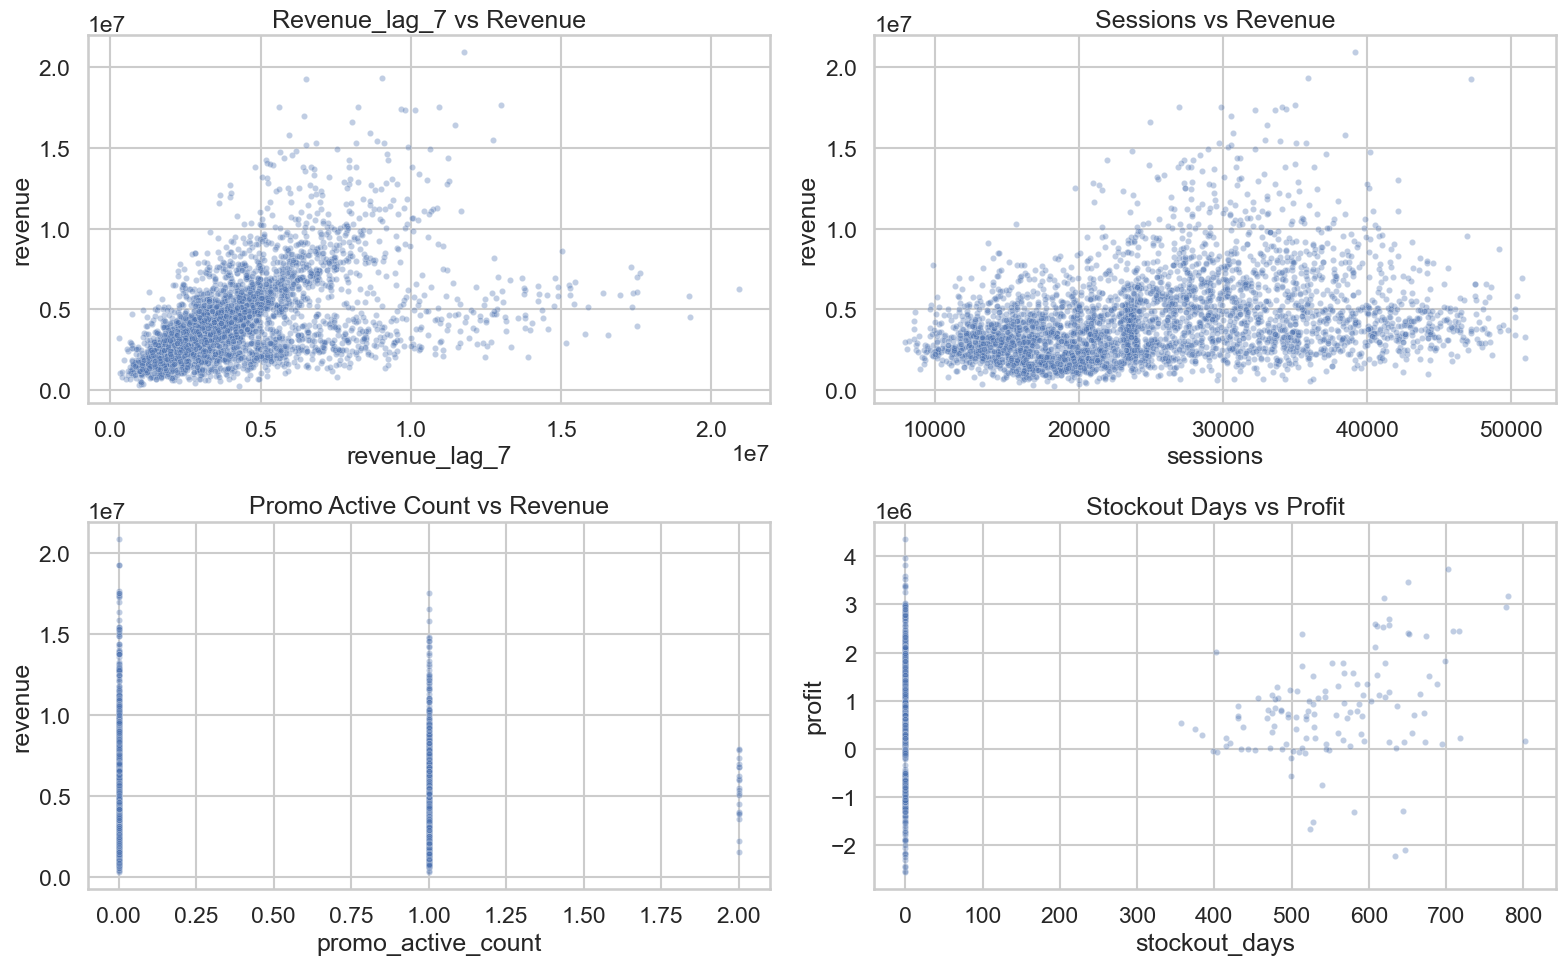

In [10]:
order_daily = orders.groupby('order_date', as_index=False)['order_id'].nunique().rename(columns={'order_date': 'date', 'order_id': 'order_count'})
refund_daily = returns.groupby('return_date', as_index=False)['refund_amount'].sum().rename(columns={'return_date': 'date', 'refund_amount': 'refund_amount_total'})
web_daily = web_traffic.groupby('date', as_index=False)['sessions'].sum()
inv_daily = inventory.groupby('snapshot_date', as_index=False).agg(stockout_days=('stockout_days', 'sum'), fill_rate=('fill_rate', 'mean')).rename(columns={'snapshot_date': 'date'})

discount_daily = (
    orders[['order_id', 'order_date']]
    .merge(order_items[['order_id', 'discount_amount']], on='order_id', how='left')
    .groupby('order_date', as_index=False)['discount_amount']
    .sum()
    .rename(columns={'order_date': 'date', 'discount_amount': 'discount_total'})
)

promo_daily = pd.DataFrame({'date': pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')})
promo_daily['promo_active_count'] = 0
for row in promotions[['start_date', 'end_date']].itertuples(index=False):
    if pd.isna(row.start_date) or pd.isna(row.end_date):
        continue
    mask = (promo_daily['date'] >= row.start_date) & (promo_daily['date'] <= row.end_date)
    promo_daily.loc[mask, 'promo_active_count'] += 1

diagnostic = (
    daily[['date', 'revenue', 'cogs', 'profit']]
    .merge(order_daily, on='date', how='left')
    .merge(web_daily, on='date', how='left')
    .merge(promo_daily, on='date', how='left')
    .merge(discount_daily, on='date', how='left')
    .merge(inv_daily, on='date', how='left')
    .merge(refund_daily, on='date', how='left')
    .sort_values('date')
)

diagnostic['revenue_lag_1'] = diagnostic['revenue'].shift(1)
diagnostic['revenue_lag_7'] = diagnostic['revenue'].shift(7)
diagnostic['sessions'] = diagnostic['sessions'].fillna(0.0)
diagnostic['order_count'] = diagnostic['order_count'].fillna(0.0)
diagnostic['conversion_rate'] = np.where(diagnostic['sessions'] > 0, diagnostic['order_count'] / diagnostic['sessions'], np.nan)
for c in ['promo_active_count', 'discount_total', 'stockout_days', 'refund_amount_total']:
    diagnostic[c] = diagnostic[c].fillna(0.0)
diagnostic['fill_rate'] = diagnostic['fill_rate'].fillna(diagnostic['fill_rate'].median())

corr_cols = [
    'revenue', 'cogs', 'profit', 'revenue_lag_1', 'revenue_lag_7',
    'sessions', 'conversion_rate', 'promo_active_count', 'discount_total',
    'stockout_days', 'fill_rate', 'refund_amount_total'
]
corr_df = diagnostic[corr_cols].dropna().copy()

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
sns.heatmap(corr_df.corr(), cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Figure 2: Revenue Driver Heatmap (association, not causation)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.scatterplot(data=diagnostic, x='revenue_lag_7', y='revenue', alpha=0.35, s=20, ax=axes[0, 0])
axes[0, 0].set_title('Revenue_lag_7 vs Revenue')
sns.scatterplot(data=diagnostic, x='sessions', y='revenue', alpha=0.35, s=20, ax=axes[0, 1])
axes[0, 1].set_title('Sessions vs Revenue')
sns.scatterplot(data=diagnostic, x='promo_active_count', y='revenue', alpha=0.35, s=20, ax=axes[1, 0])
axes[1, 0].set_title('Promo Active Count vs Revenue')
sns.scatterplot(data=diagnostic, x='stockout_days', y='profit', alpha=0.35, s=20, ax=axes[1, 1])
axes[1, 1].set_title('Stockout Days vs Profit')
plt.tight_layout()
plt.show()

## Layer 3 - Predictive (What is likely to happen?)

Model narrative in notebook:
- Baseline: seasonal profile + trend (YoY growth)
- Feature model: lag + rolling + calendar
- Validation: strict time split (train <= 2020, validate 2021-2022) plus TimeSeriesSplit folds

,model,MAE,RMSE,R2,MAPE_%,sMAPE_%
0,Baseline seasonal+trend,590854.6148,787770.8791,0.7767,23.5179,20.9409
1,Feature model (lag+rolling+calendar),568661.5243,826395.0450,0.7542,22.5085,19.7758


,model,MAE,RMSE,R2,MAPE_%,sMAPE_%
0,TSCV fold 1,9.330370e+05,1.389380e+06,0.7332,20.5302,18.6292
1,TSCV fold 2,1.091733e+06,1.678318e+06,0.7147,20.9354,18.7446
2,TSCV fold 3,7.697003e+05,1.169924e+06,0.8172,21.8966,18.3533
3,TSCV fold 4,5.882936e+05,7.824940e+05,0.7463,32.6072,24.3962
4,TSCV fold 5,5.630466e+05,7.830543e+05,0.7682,22.1784,19.5808


,MAE,RMSE,R2,MAPE_%,sMAPE_%
TSCV mean,789162.1787,1.160634e+06,0.7559,23.6296,19.9408


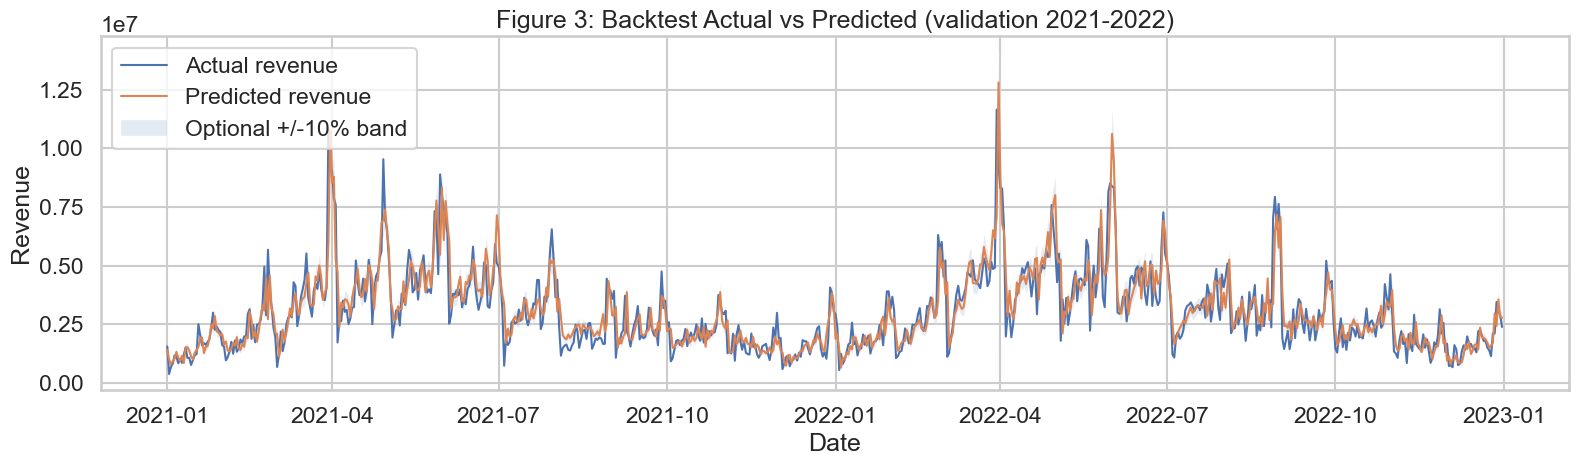

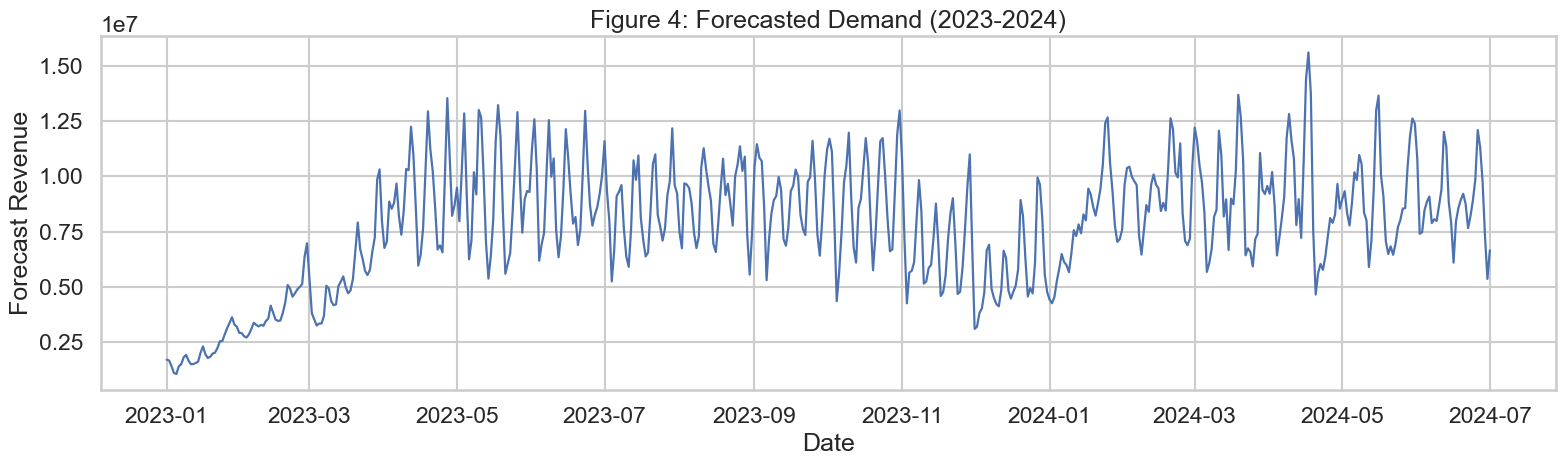

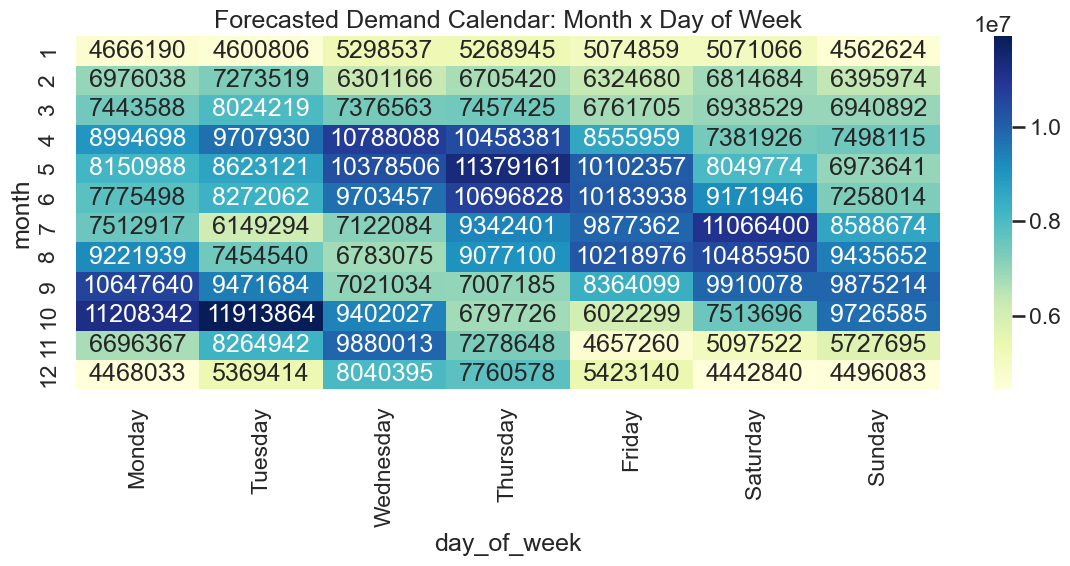

In [11]:
series = daily[['date', 'revenue']].copy()
feat = add_ts_features(series).dropna().reset_index(drop=True)

feature_cols = [
    'day_of_week', 'month', 'day_of_year', 'is_weekend',
    'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_14', 'revenue_lag_28',
    'revenue_roll_mean_7', 'revenue_roll_std_7', 'revenue_roll_mean_28', 'revenue_roll_std_28'
]

train_mask = feat['date'] < pd.Timestamp('2021-01-01')
valid_mask = (feat['date'] >= pd.Timestamp('2021-01-01')) & (feat['date'] <= pd.Timestamp('2022-12-31'))
x_train, y_train = feat.loc[train_mask, feature_cols], feat.loc[train_mask, 'revenue']
x_valid, y_valid = feat.loc[valid_mask, feature_cols], feat.loc[valid_mask, 'revenue']

baseline_state = fit_seasonal_trend_baseline(series[series['date'] < pd.Timestamp('2021-01-01')])
baseline_valid = predict_seasonal_trend(baseline_state, feat.loc[valid_mask, 'date'])

hgb = HistGradientBoostingRegressor(loss='squared_error', learning_rate=0.05, max_depth=8, max_iter=400, random_state=42)
hgb.fit(x_train, y_train)
valid_pred = hgb.predict(x_valid)

metrics = [
    compute_metrics(y_valid.values, baseline_valid['pred'].values, 'Baseline seasonal+trend'),
    compute_metrics(y_valid.values, valid_pred, 'Feature model (lag+rolling+calendar)'),
]
metrics_df = pd.DataFrame(metrics)
display(metrics_df.round(4))

tscv = TimeSeriesSplit(n_splits=5)
feat_for_cv = feat[feat['date'] <= pd.Timestamp('2022-12-31')].reset_index(drop=True)
cv_rows = []
for i, (tr_idx, te_idx) in enumerate(tscv.split(feat_for_cv), start=1):
    x_tr = feat_for_cv.loc[tr_idx, feature_cols]
    y_tr = feat_for_cv.loc[tr_idx, 'revenue']
    x_te = feat_for_cv.loc[te_idx, feature_cols]
    y_te = feat_for_cv.loc[te_idx, 'revenue']

    model_fold = HistGradientBoostingRegressor(loss='squared_error', learning_rate=0.05, max_depth=8, max_iter=400, random_state=42)
    model_fold.fit(x_tr, y_tr)
    pred_fold = model_fold.predict(x_te)
    cv_rows.append(compute_metrics(y_te.values, pred_fold, f'TSCV fold {i}'))

cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(4))
display(cv_df[['MAE', 'RMSE', 'R2', 'MAPE_%', 'sMAPE_%']].mean().rename('TSCV mean').to_frame().T.round(4))

backtest = pd.DataFrame({'date': feat.loc[valid_mask, 'date'], 'actual': y_valid.values, 'pred': valid_pred})
fig, ax = plt.subplots(1, 1, figsize=(16, 5))
ax.plot(backtest['date'], backtest['actual'], label='Actual revenue', linewidth=1.5)
ax.plot(backtest['date'], backtest['pred'], label='Predicted revenue', linewidth=1.5)
ax.fill_between(backtest['date'], backtest['pred'] * 0.9, backtest['pred'] * 1.1, alpha=0.15, label='Optional +/-10% band')
ax.set_title('Figure 3: Backtest Actual vs Predicted (validation 2021-2022)')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

hgb_full = HistGradientBoostingRegressor(loss='squared_error', learning_rate=0.05, max_depth=8, max_iter=400, random_state=42)
hgb_full.fit(feat[feature_cols], feat['revenue'])
future_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
future_forecast = recursive_forecast_hgb(series, hgb_full, future_dates).rename(columns={'pred': 'forecast_revenue'})

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
ax.plot(future_forecast['date'], future_forecast['forecast_revenue'], linewidth=1.6)
ax.set_title('Figure 4: Forecasted Demand (2023-2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Forecast Revenue')
plt.tight_layout()
plt.show()

cal = future_forecast.copy()
cal['month'] = cal['date'].dt.month
cal['day_of_week'] = cal['date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cal['day_of_week'] = pd.Categorical(cal['day_of_week'], categories=dow_order, ordered=True)
calendar_heatmap = cal.pivot_table(index='month', columns='day_of_week', values='forecast_revenue', aggfunc='mean')

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
sns.heatmap(calendar_heatmap, cmap='YlGnBu', annot=True, fmt='.0f', ax=ax)
ax.set_title('Forecasted Demand Calendar: Month x Day of Week')
plt.tight_layout()
plt.show()

## Layer 4 - Prescriptive (What should we do?)

Operational rules implemented from the story:
- Inventory pre-positioning
- Promotion timing
- Logistics capacity planning
- Profit protection via net profit proxy

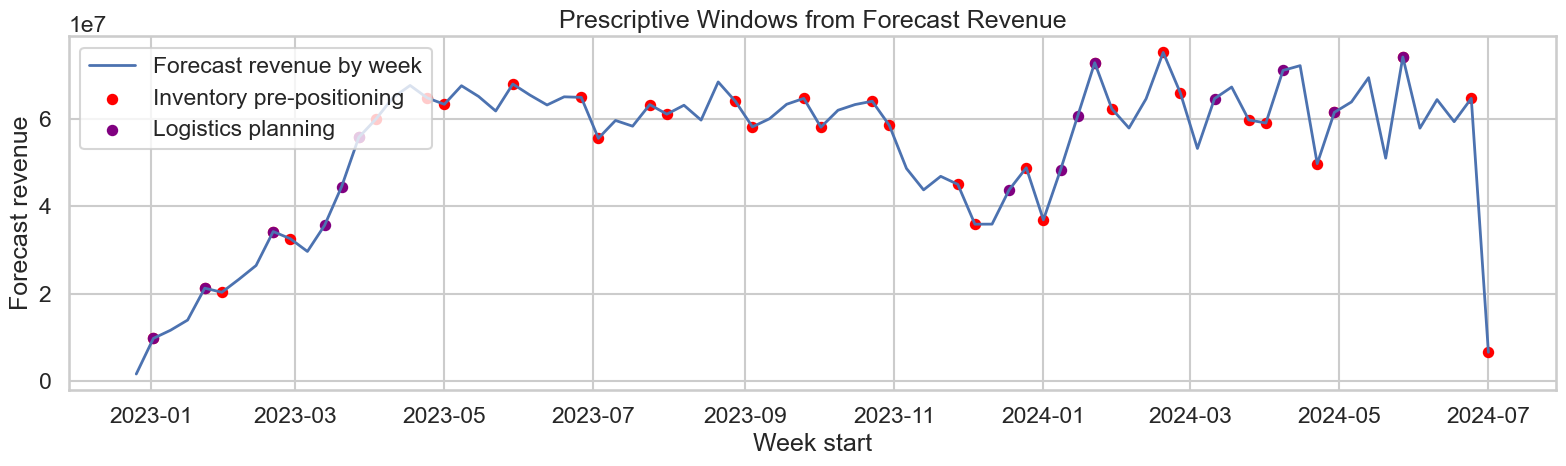

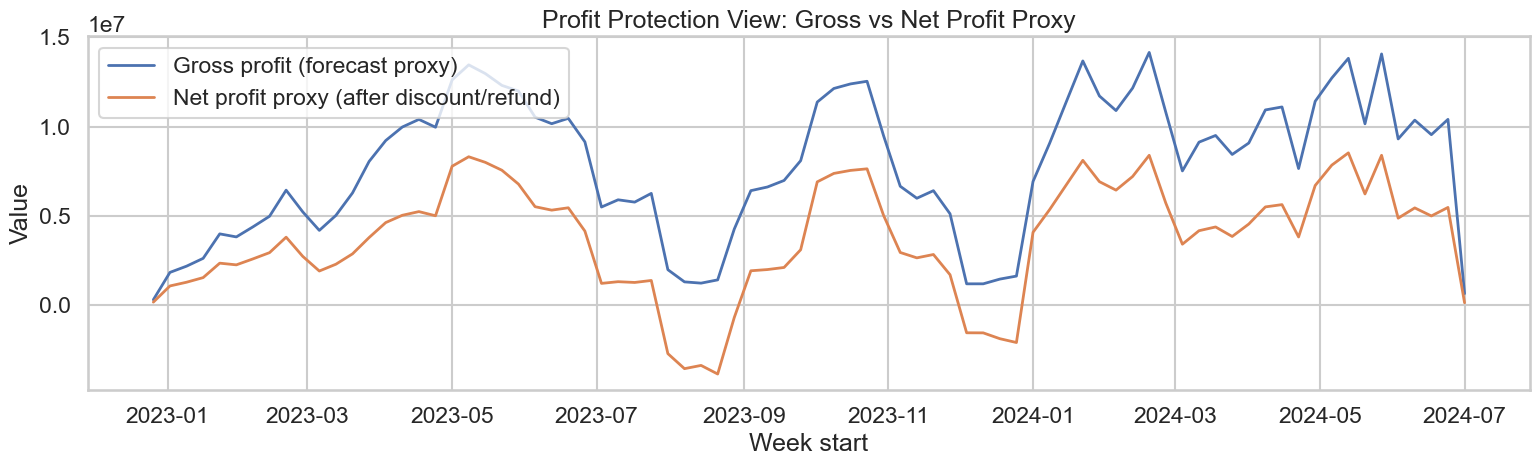

,week_start,forecast_revenue,avg_stockout_days,avg_conversion_rate,margin,action_inventory_preposition,action_promo_timing,action_logistics_capacity,action_profit_protection
60,2024-02-19,7.509731e+07,6.242857,0.008061,0.188609,True,False,False,False
74,2024-05-27,7.404977e+07,89.571429,0.011331,0.188586,True,False,True,False
56,2024-01-22,7.274183e+07,12.728571,0.008693,0.188153,True,False,True,False
68,2024-04-15,7.207447e+07,0.000000,0.006570,0.154154,False,False,False,False
67,2024-04-08,7.098971e+07,0.000000,0.005651,0.154154,False,False,True,False
72,2024-05-13,6.933210e+07,0.000000,0.007022,0.199532,False,False,False,False
34,2023-08-21,6.835449e+07,0.000000,0.005799,0.020899,False,False,False,True
22,2023-05-29,6.788415e+07,89.571429,0.011331,0.177640,True,False,False,False
16,2023-04-17,6.755467e+07,0.000000,0.006570,0.154154,False,False,False,False
19,2023-05-08,6.749360e+07,0.000000,0.005630,0.199532,False,False,False,False


,action,weeks_flagged
0,inventory_preposition,35
1,promo_timing,10
2,logistics_capacity,14
3,profit_protection,24


In [12]:
hist_fin = daily[['date', 'revenue', 'cogs']].copy()
hist_fin = hist_fin.merge(refund_daily, on='date', how='left').merge(discount_daily, on='date', how='left')
hist_fin[['refund_amount_total', 'discount_total']] = hist_fin[['refund_amount_total', 'discount_total']].fillna(0.0)
hist_fin['gross_profit'] = hist_fin['revenue'] - hist_fin['cogs']
hist_fin['net_profit_proxy'] = hist_fin['revenue'] - hist_fin['cogs'] - hist_fin['refund_amount_total'] - hist_fin['discount_total']
hist_fin['gross_margin'] = np.where(hist_fin['revenue'] != 0, hist_fin['gross_profit'] / hist_fin['revenue'], np.nan)

hist_fin['month'] = hist_fin['date'].dt.month
hist_fin['day_of_week'] = hist_fin['date'].dt.dayofweek
cogs_ratio_by_month = (hist_fin.groupby('month').apply(lambda d: d['cogs'].sum() / d['revenue'].sum())).to_dict()
discount_ratio_by_dow = (hist_fin.groupby('day_of_week').apply(lambda d: d['discount_total'].sum() / d['revenue'].sum())).to_dict()
refund_ratio_by_dow = (hist_fin.groupby('day_of_week').apply(lambda d: d['refund_amount_total'].sum() / d['revenue'].sum())).to_dict()

future = future_forecast.copy()
future['month'] = future['date'].dt.month
future['day_of_week'] = future['date'].dt.dayofweek
future['est_cogs'] = future['month'].map(cogs_ratio_by_month).fillna(np.mean(list(cogs_ratio_by_month.values()))) * future['forecast_revenue']
future['est_discount'] = future['day_of_week'].map(discount_ratio_by_dow).fillna(np.mean(list(discount_ratio_by_dow.values()))) * future['forecast_revenue']
future['est_refund'] = future['day_of_week'].map(refund_ratio_by_dow).fillna(np.mean(list(refund_ratio_by_dow.values()))) * future['forecast_revenue']
future['gross_profit'] = future['forecast_revenue'] - future['est_cogs']
future['net_profit_proxy'] = future['forecast_revenue'] - future['est_cogs'] - future['est_discount'] - future['est_refund']
future['margin'] = np.where(future['forecast_revenue'] != 0, future['gross_profit'] / future['forecast_revenue'], np.nan)

hist_90 = hist_fin[hist_fin['date'] >= hist_fin['date'].max() - pd.Timedelta(days=89)]
threshold_inventory = hist_90['revenue'].mean() + hist_90['revenue'].std()

stockout_profile = diagnostic.copy()
stockout_profile['week_of_year'] = stockout_profile['date'].dt.isocalendar().week.astype(int)
stockout_week_profile = stockout_profile.groupby('week_of_year', as_index=False)['stockout_days'].mean().rename(columns={'stockout_days': 'avg_stockout_days'})

conversion_profile = diagnostic.copy()
conversion_profile['week_of_year'] = conversion_profile['date'].dt.isocalendar().week.astype(int)
conversion_week_profile = conversion_profile.groupby('week_of_year', as_index=False)['conversion_rate'].mean().rename(columns={'conversion_rate': 'avg_conversion_rate'})

future_week = future.copy()
future_week['week_start'] = future_week['date'] - pd.to_timedelta(future_week['date'].dt.dayofweek, unit='D')
future_week['week_of_year'] = future_week['date'].dt.isocalendar().week.astype(int)

weekly = future_week.groupby(['week_start', 'week_of_year'], as_index=False).agg(
    forecast_revenue=('forecast_revenue', 'sum'),
    gross_profit=('gross_profit', 'sum'),
    net_profit_proxy=('net_profit_proxy', 'sum'),
    margin=('margin', 'mean'),
)
weekly = weekly.merge(stockout_week_profile, on='week_of_year', how='left').merge(conversion_week_profile, on='week_of_year', how='left')
weekly[['avg_stockout_days', 'avg_conversion_rate']] = weekly[['avg_stockout_days', 'avg_conversion_rate']].fillna(0.0)

stockout_high_cutoff = stockout_profile['stockout_days'].quantile(0.75)
low_demand_cutoff = weekly['forecast_revenue'].quantile(0.30)
margin_cutoff = hist_fin['gross_margin'].median()
conversion_cutoff = conversion_profile['conversion_rate'].quantile(0.40)

weekly['action_inventory_preposition'] = (weekly['forecast_revenue'] > threshold_inventory) & (weekly['avg_stockout_days'] > stockout_high_cutoff)
weekly['action_promo_timing'] = (weekly['forecast_revenue'] < low_demand_cutoff) & (weekly['margin'] > margin_cutoff) & (weekly['avg_conversion_rate'] > conversion_cutoff)
weekly['revenue_wow_growth'] = weekly['forecast_revenue'].pct_change()
weekly['action_logistics_capacity'] = weekly['revenue_wow_growth'] > 0.20
weekly['action_profit_protection'] = weekly['net_profit_proxy'] < weekly['net_profit_proxy'].quantile(0.30)

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
ax.plot(weekly['week_start'], weekly['forecast_revenue'], label='Forecast revenue by week', linewidth=2)
ax.scatter(weekly.loc[weekly['action_inventory_preposition'], 'week_start'], weekly.loc[weekly['action_inventory_preposition'], 'forecast_revenue'], color='red', s=45, label='Inventory pre-positioning')
ax.scatter(weekly.loc[weekly['action_logistics_capacity'], 'week_start'], weekly.loc[weekly['action_logistics_capacity'], 'forecast_revenue'], color='purple', s=45, label='Logistics planning')
ax.set_title('Prescriptive Windows from Forecast Revenue')
ax.set_xlabel('Week start')
ax.set_ylabel('Forecast revenue')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
ax.plot(weekly['week_start'], weekly['gross_profit'], label='Gross profit (forecast proxy)', linewidth=2)
ax.plot(weekly['week_start'], weekly['net_profit_proxy'], label='Net profit proxy (after discount/refund)', linewidth=2)
ax.set_title('Profit Protection View: Gross vs Net Profit Proxy')
ax.set_xlabel('Week start')
ax.set_ylabel('Value')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

playbook_view = weekly[['week_start', 'forecast_revenue', 'avg_stockout_days', 'avg_conversion_rate', 'margin', 'action_inventory_preposition', 'action_promo_timing', 'action_logistics_capacity', 'action_profit_protection']].copy()
playbook_view = playbook_view.sort_values('forecast_revenue', ascending=False)
display(playbook_view.head(15))
display(pd.DataFrame({
    'action': ['inventory_preposition', 'promo_timing', 'logistics_capacity', 'profit_protection'],
    'weeks_flagged': [
        int(weekly['action_inventory_preposition'].sum()),
        int(weekly['action_promo_timing'].sum()),
        int(weekly['action_logistics_capacity'].sum()),
        int(weekly['action_profit_protection'].sum()),
    ],
}))